# **Lesson 1 - Bell States** 

We begin by importing what we need from `Qiskit`,

In [3]:
# Importing Qiskit libraries,
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeVigoV2

# Importing other libraries,
import matplotlib.pyplot as plt

Our first objective will be to create a **Bell state** consisting of two entangled qubits. We will do this by simulating a specialised quantum circuit made from a **Hadamad gate** and a **CNOT** gate. The boiler plate code is as follows,

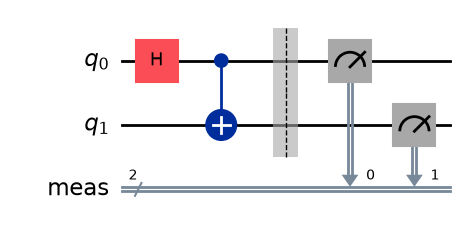

In [4]:
bell_cir = QuantumCircuit(2) # Creating a quantum circuit with 2 qubits.
bell_cir.h(0) # Applying Hadamard gate to first qubit.
bell_cir.cx(control_qubit=0, target_qubit=1) # Applying CNOT gate to the entangle first and second qubits.
bell_cir.measure_all() # Measuring all qubits at the end of the circuit.
bell_cir.draw(output="mpl") # Drawing the circuit.

Now we want to run the circuit on a simulator. We define a function `run` that takes `circuit`, `backend` and `shots` as arguments. The bankend, whether that be a simuluator or real device, takes the circuit object and converts it into a device-specific form. The number of shots refers to the number of times the circuit should be ran. It is important to choose an appropriate shot number that allows for reliable statistics, but balances computational costs. In our case, the backend is the `AerSimulator` which is a high-performance quantum computing simulator written in C++ tha can simulate realistic noise models. The boilerplate code is,   

In [34]:
def run_simulator(circuit, shots, method="automatic", device="CPU", noise=False):
    """
    Function to run the quantum circuit on the AER simulator.
    
    Parameters:
    circuit (QuantumCircuit): The quantum circuit to be executed.
    shots (int): The number of shots to run the circuit for. 
    Also known as the number of times the circuit is executed.
    device (str): The device to run the simulation on. Can be "CPU" or "GPU". Default is "CPU".
    noise (bool): Whether to use a noise model (FakeVigoV2) or not. Default is False.

    Returns:
    result: The result object of the simulatuation. Use .get_counts() to get the counts of the resulting states.
    """

    # Creating the simulation backend,
    if noise:
        device_backend = FakeVigoV2() # <-- Noise model.
        simulator = qiskit_aer.AerSimulator.from_backend(device_backend, method=method, device=device)
    else:
        simulator = qiskit_aer.AerSimulator(method=method, device=device)

    # Transpiling the circuit,,
    cir_transpiled = qiskit.transpile(circuit, simulator)

    # Running simulator,
    result = simulator.run(cir_transpiled, shots=shots).result()

    # Returning result,
    return result

Note that AER simulator can use various methods such that `statevector`, `density_matrix`, `stabilizer`, etc. (see documentation). Running the simulator with no noise model,

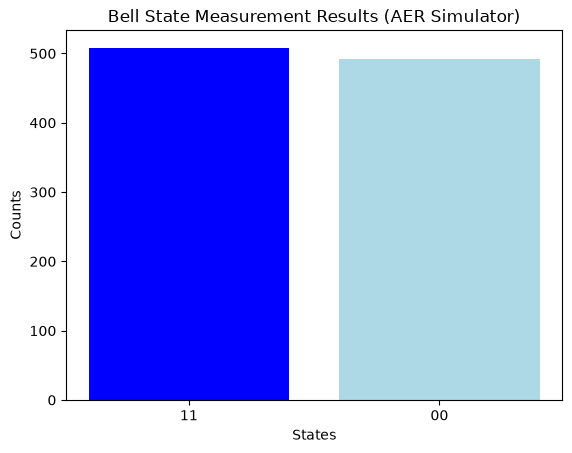

In [38]:
# Running simulation,
results = run_simulator(circuit=bell_cir, shots=1000, noise=False)
counts = results.get_counts(bell_cir)

# Plotting results,
plt.bar(counts.keys(), counts.values(), color=["blue", "lightblue"])
plt.xlabel("States")
plt.ylabel("Counts")
plt.title("Bell State Measurement Results (AER Simulator)")
plt.show()

As expected we get almost an even split of states. With noise, we expect the other states to be counted,

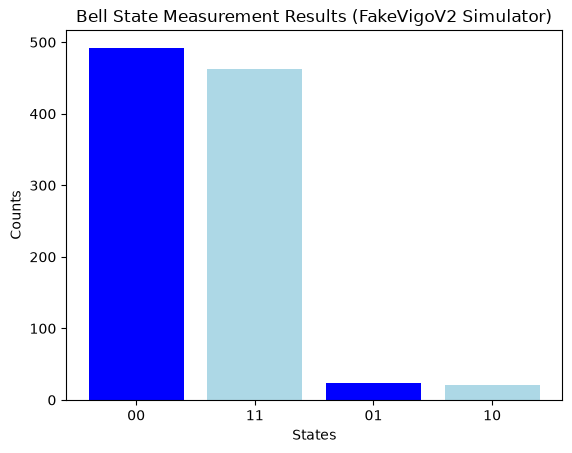

In [37]:
# Running simulation,
results = run_simulator(circuit=bell_cir, shots=1000, noise=True)
counts = results.get_counts(bell_cir)

# Plotting results,
plt.bar(counts.keys(), counts.values(), color=["blue", "lightblue"])
plt.xlabel("States")
plt.ylabel("Counts")
plt.title("Bell State Measurement Results (FakeVigoV2 Simulator)")
plt.show()

It is important to distinguish the noise model from the simulator. 

# Refereneces

Qiskit Aer 0.17.1 (Docs). Simulators. URL: https://qiskit.github.io/qiskit-aer/tutorials/1_aersimulator.html.